In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
import random
import joblib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
TRA = pd.read_csv("Data/TrainingData.csv")

In [3]:
TRA

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector1_Rank,Sector2_Rank,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart
0,ALB,Williams,11.000000,0.000000,0.0,83.130,81.847,81.664,36.650031,20.898312,...,8,11,9,100.490737,4.395648,11,8.162887,0.0,0.0,240.0
1,ALO,Aston Martin,11.000000,0.000000,0.0,82.065,84.662,82.720,35.042333,23.232611,...,3,18,18,108.596878,12.501790,18,13.597315,0.0,0.0,289.0
2,ANT,Mercedes,11.000000,0.000000,0.0,81.376,79.943,80.324,36.042935,19.788161,...,5,1,4,97.629652,1.534564,3,3.429035,0.0,0.0,12.0
3,BEA,Haas F1 Team,11.000000,0.000000,0.0,82.682,81.326,80.778,39.039839,20.835774,...,15,10,5,101.749399,5.654310,17,9.836708,0.0,0.0,108.0
4,BOR,Audi,11.000000,0.000000,0.0,81.696,81.668,80.459,39.209964,20.777286,...,17,8,17,106.696170,10.601082,9,7.313140,0.0,0.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,PIA,McLaren,7.666667,11.333333,30.5,74.963,73.299,74.793,27.788600,27.393933,...,22,16,21,92.187700,6.704102,20,6.324583,376.0,4042.0,24.0
103,RUS,Mercedes,6.666667,9.333333,37.0,73.544,72.965,74.702,24.087889,26.450421,...,1,2,19,87.064663,1.581064,7,3.008375,180.0,14400.0,4.0
104,SAI,Williams,8.000000,5.000000,1.5,76.660,74.536,75.943,26.809000,27.738625,...,17,20,5,89.124475,3.640877,8,3.131158,75.0,20.0,180.0
105,STR,Aston Martin,12.666667,6.333333,0.0,76.978,76.354,77.120,26.713857,27.152500,...,16,10,20,90.767786,5.284187,22,6.938000,0.0,0.0,420.0


In [4]:
X = TRA.drop(["Driver","Constructor","Race_Result"],axis=1)

In [5]:
X.columns

Index(['AveragePositionFromLast3Races', 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)', 'Sector1Time(s)',
       'Sector2Time(s)', 'Sector3Time(s)', 'Average_Laptime(s)',
       'Qualifying_Time(s)', 'Starting_Pos', 'DriverPoints',
       'ConstructorPoints', 'FP1_Rank', 'FP2_Rank', 'FP3_Rank',
       'FP1_DeltaToFastest', 'FP2_DeltaToFastest', 'FP3_DeltaToFastest',
       'Sector1_Rank', 'Sector2_Rank', 'Sector3_Rank', 'CombinedSectorTime',
       'CombinedSectorDelta', 'LapTime_Rank', 'DeltaToFastestLap',
       'StartXConst', 'DriXConst', 'FP3XStart'],
      dtype='object')

In [6]:
y = TRA["Race_Result"]

In [7]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y, test_size = 0.2, random_state = 23)

In [9]:
model = RandomForestRegressor()

In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None]
}

In [11]:
regcv = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [12]:
regcv.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [13]:
y_pred = regcv.predict(X_test)

In [14]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.21529869444027194


In [16]:
scores = []

for r in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed,
        y,
        test_size=0.35,
        random_state=r
    )

    regcv.fit(X_train, y_train)
    y_pred = regcv.predict(X_test)

    corr, _ = spearmanr(y_pred, y_test)
    scores.append(corr)
    print (f"{r+1} Done.")

print("Mean Spearman:", np.mean(scores))
print("Std Spearman:", np.std(scores))
print("Best:", np.max(scores))

1 Done.
2 Done.
3 Done.
4 Done.
5 Done.
6 Done.
7 Done.
8 Done.
9 Done.
10 Done.
11 Done.
12 Done.
13 Done.
14 Done.
15 Done.
16 Done.
17 Done.
18 Done.
19 Done.
20 Done.
21 Done.
22 Done.
23 Done.
24 Done.
25 Done.
26 Done.
27 Done.
28 Done.
29 Done.
30 Done.
31 Done.
32 Done.
33 Done.
34 Done.
35 Done.
36 Done.
37 Done.
38 Done.
39 Done.
40 Done.
41 Done.
42 Done.
43 Done.
44 Done.
45 Done.
46 Done.
47 Done.
48 Done.
49 Done.
50 Done.
Mean Spearman: 0.4944391242453699
Std Spearman: 0.10273124778175793
Best: 0.6888435437887079


In [19]:
maxm = 0
rand = 0 
for i in range (50):
    if scores[i]>maxm:
        maxm = scores[i]
        rand = i

print (maxm)
print (rand)

0.6888435437887079
36


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
        X_imputed,
        y,
        test_size=0.35,
        random_state=rand
    )

regcv.fit(X_train, y_train)
y_pred = regcv.predict(X_test)

corr, _ = spearmanr(y_pred, y_test)

In [22]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

In [24]:
X.columns

Index(['AveragePositionFromLast3Races', 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)', 'Sector1Time(s)',
       'Sector2Time(s)', 'Sector3Time(s)', 'Average_Laptime(s)',
       'Qualifying_Time(s)', 'Starting_Pos', 'DriverPoints',
       'ConstructorPoints', 'FP1_Rank', 'FP2_Rank', 'FP3_Rank',
       'FP1_DeltaToFastest', 'FP2_DeltaToFastest', 'FP3_DeltaToFastest',
       'Sector1_Rank', 'Sector2_Rank', 'Sector3_Rank', 'CombinedSectorTime',
       'CombinedSectorDelta', 'LapTime_Rank', 'DeltaToFastestLap',
       'StartXConst', 'DriXConst', 'FP3XStart'],
      dtype='object')

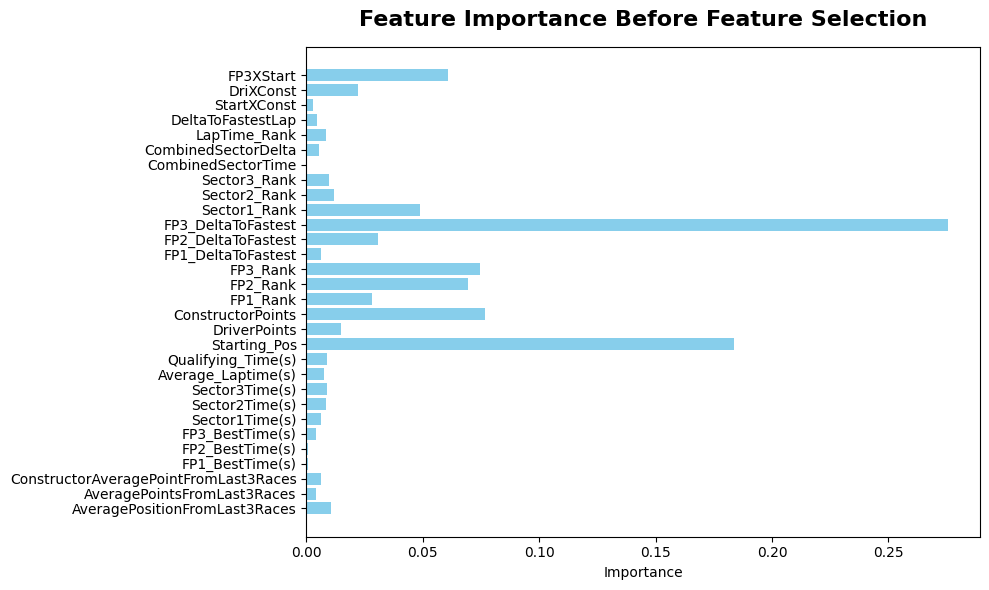

In [23]:


plt.figure(figsize=(10,6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance Before Feature Selection", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Plots/Feature_importance_in_1st_itration.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
columns = ['AveragePositionFromLast3Races', 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)', 'Sector1Time(s)',
       'Sector2Time(s)', 'Sector3Time(s)', 'Average_Laptime(s)',
       'Qualifying_Time(s)', 
       'FP1_DeltaToFastest',
        'Sector2_Rank', 'Sector3_Rank', 'CombinedSectorTime',
       'CombinedSectorDelta', 'LapTime_Rank', 'DeltaToFastestLap',
       'StartXConst',"Race_Result","Driver","Constructor"]

In [31]:
X = TRA.drop(columns,axis=1)

In [32]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [33]:
scores = []

for r in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed,
        y,
        test_size=0.35,
        random_state=r
    )

    regcv.fit(X_train, y_train)
    y_pred = regcv.predict(X_test)

    corr, _ = spearmanr(y_pred, y_test)
    scores.append(corr)
    print (f"{r+1} Done.")

print("Mean Spearman:", np.mean(scores))
print("Std Spearman:", np.std(scores))
print("Best:", np.max(scores))

1 Done.
2 Done.
3 Done.
4 Done.
5 Done.
6 Done.
7 Done.
8 Done.
9 Done.
10 Done.
11 Done.
12 Done.
13 Done.
14 Done.
15 Done.
16 Done.
17 Done.
18 Done.
19 Done.
20 Done.
21 Done.
22 Done.
23 Done.
24 Done.
25 Done.
26 Done.
27 Done.
28 Done.
29 Done.
30 Done.
31 Done.
32 Done.
33 Done.
34 Done.
35 Done.
36 Done.
37 Done.
38 Done.
39 Done.
40 Done.
41 Done.
42 Done.
43 Done.
44 Done.
45 Done.
46 Done.
47 Done.
48 Done.
49 Done.
50 Done.
Mean Spearman: 0.5359914135847429
Std Spearman: 0.08615273565990902
Best: 0.7111076230834781


In [34]:
maxm = 0
rand = 0 
for i in range (50):
    if scores[i]>maxm:
        maxm = scores[i]
        rand = i

print (maxm)
print (rand)

0.7111076230834781
39


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
        X_imputed,
        y,
        test_size=0.35,
        random_state=rand
    )

regcv.fit(X_train, y_train)
y_pred = regcv.predict(X_test)

corr, _ = spearmanr(y_pred, y_test)
print(corr)

0.6957583990267887


In [38]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

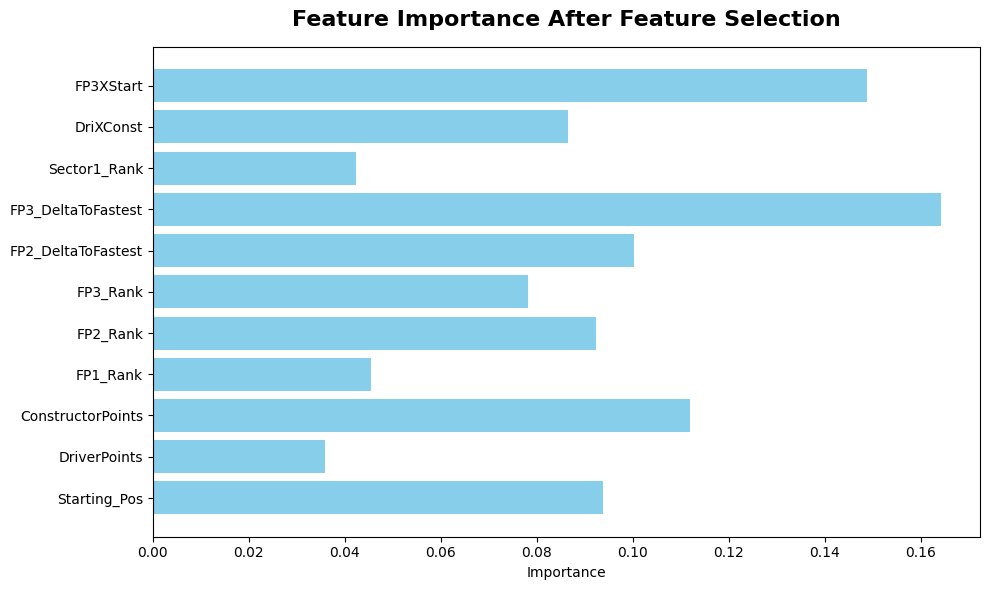

In [39]:


plt.figure(figsize=(10,6))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance After Feature Selection", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("Plots/Feature_importance_in_2nd_itration.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
joblib.dump(regcv, "Model/RandomForestModel71.pkl")

['Model/RandomForestModel71.pkl']

In [67]:
MON = pd.read_csv("Data/MonacoGP.csv")

In [68]:

MON.dropna(subset=['Qualifying_Time(s)'],inplace=True)
MON['FP1_BestTime(s)'].fillna(MON['FP1_BestTime(s)'].median(),inplace=True)
MON['FP2_BestTime(s)'].fillna(MON['FP2_BestTime(s)'].median(),inplace=True)
MON['FP3_BestTime(s)'].fillna(MON['FP3_BestTime(s)'].median(),inplace=True)
MON['Sector1Time(s)'].fillna(MON['Sector1Time(s)'].median(),inplace=True)
MON['Sector2Time(s)'].fillna(MON['Sector2Time(s)'].median(),inplace=True)
MON['Sector3Time(s)'].fillna(MON['Sector3Time(s)'].median(),inplace=True)
MON['Average_Laptime(s)'].fillna(MON['Average_Laptime(s)'].mean(),inplace=True)
MON['AveragePointsFromLast3Races'].fillna(0,inplace=True)

print("Data Cleaning Done")

MON=MON.sort_values('FP1_BestTime(s)', ascending=True).reset_index(drop=True)
MON['FP1_Rank'] = MON.index+1
MON=MON.sort_values('FP2_BestTime(s)', ascending=True).reset_index(drop=True)
MON['FP2_Rank'] = MON.index+1
MON=MON.sort_values('FP3_BestTime(s)', ascending=True).reset_index(drop=True)
MON['FP3_Rank'] = MON.index+1

MON['FP1_DeltaToFastest'] = MON['FP1_BestTime(s)'] - MON['FP1_BestTime(s)'].min()
MON['FP2_DeltaToFastest'] = MON['FP2_BestTime(s)'] - MON['FP2_BestTime(s)'].min()
MON['FP3_DeltaToFastest'] = MON['FP3_BestTime(s)'] - MON['FP3_BestTime(s)'].min()

MON=MON.sort_values('Sector1Time(s)', ascending=True).reset_index(drop=True)
MON['Sector1_Rank'] = MON.index+1
MON=MON.sort_values('Sector2Time(s)', ascending=True).reset_index(drop=True)
MON['Sector2_Rank'] = MON.index+1
MON=MON.sort_values('Sector3Time(s)', ascending=True).reset_index(drop=True)
MON['Sector3_Rank'] = MON.index+1

MON['CombinedSectorTime'] = MON['Sector1Time(s)']+MON['Sector2Time(s)']+MON['Sector3Time(s)']
MON['CombinedSectorDelta'] = MON['CombinedSectorTime']-MON['CombinedSectorTime'].min()

MON=MON.sort_values('Average_Laptime(s)', ascending=True).reset_index(drop=True)
MON['LapTime_Rank'] = MON.index+1

MON['DeltaToFastestLap'] = MON['Average_Laptime(s)'] - MON['Average_Laptime(s)'].min()

MON['StartXConst'] = MON['Starting_Pos']*MON['ConstructorPoints']
MON['DriXConst'] = MON['DriverPoints']*MON['ConstructorPoints']
MON['FP3XStart'] = MON['FP3_Rank']*MON['Starting_Pos']


MON = MON.sort_values('Driver', ascending=True).reset_index(drop=True)

MON

Data Cleaning Done


/tmp/ipykernel_82223/2755371838.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MON['FP1_BestTime(s)'].fillna(MON['FP1_BestTime(s)'].median(),inplace=True)
/tmp/ipykernel_82223/2755371838.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector1_Rank,Sector2_Rank,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart
0,ALB,Williams,10.333333,5.666667,2.5,75.989,74.600,74.801,22.480769,40.787447,...,2,11,9,88.550772,3.060224,8,4.330093,77.0,7.0,176.0
1,ALO,Aston Martin,11.666667,5.833333,0.0,76.678,75.294,75.567,22.958833,40.708207,...,6,9,13,89.604640,4.114092,10,4.500591,0.0,0.0,441.0
2,ANT,Mercedes,9.000000,17.000000,31.0,74.537,73.529,72.720,23.736771,42.723088,...,17,22,17,93.315118,7.824569,19,6.691904,219.0,28689.0,1.0
3,BEA,Haas F1 Team,7.333333,3.666667,0.5,76.292,74.456,74.487,24.486622,41.533528,...,22,16,5,90.913907,5.423359,5,3.585090,361.0,342.0,266.0
4,BOR,Audi,8.333333,4.166667,0.0,75.750,74.359,73.820,23.170286,40.086714,...,11,5,20,90.899000,5.408452,17,6.449516,32.0,4.0,112.0
5,BOT,Cadillac,11.333333,5.666667,0.0,77.460,75.759,75.451,23.337667,40.748185,...,14,10,2,86.730012,1.239463,2,1.119871,0.0,0.0,400.0
6,COL,Alpine,7.000000,6.500000,9.0,76.189,74.758,75.179,24.279387,41.603032,...,19,17,10,91.198493,5.707945,12,5.543871,490.0,525.0,266.0
7,GAS,Alpine,11.000000,5.500000,9.0,75.828,74.497,74.480,24.386378,39.974889,...,20,4,4,89.212176,3.721628,6,3.805750,315.0,700.0,117.0
8,HAD,Red Bull Racing,12.333333,6.166667,17.5,76.148,74.087,73.877,23.117913,40.684348,...,9,8,19,91.060629,5.570081,18,6.488503,285.0,798.0,40.0
9,HAM,Ferrari,8.666667,8.333333,21.0,74.204,73.026,73.051,24.465500,41.936057,...,21,19,18,93.499432,8.008884,21,8.259933,441.0,10584.0,9.0


In [69]:
columns = ['AveragePositionFromLast3Races', 'AveragePointsFromLast3Races',
       'ConstructorAveragePointFromLast3Races', 'FP1_BestTime(s)',
       'FP2_BestTime(s)', 'FP3_BestTime(s)', 'Sector1Time(s)',
       'Sector2Time(s)', 'Sector3Time(s)', 'Average_Laptime(s)',
       'Qualifying_Time(s)', 
       'FP1_DeltaToFastest',
        'Sector2_Rank', 'Sector3_Rank', 'CombinedSectorTime',
       'CombinedSectorDelta', 'LapTime_Rank', 'DeltaToFastestLap',
       'StartXConst',"Driver","Constructor"]

In [70]:
X = MON.drop(columns,axis=1)

In [71]:
X_imputed = imputer.transform(X)

In [72]:
y_pred = regcv.predict(X_imputed)

In [73]:
MON["Predicted_Result"] = y_pred

In [74]:
MON = MON.sort_values(by="Predicted_Result", ascending=True)
MON = MON.reset_index(drop=True)
MON["Predicted_Pos"] = MON.index + 1

In [75]:
MON

,Driver,Constructor,AveragePositionFromLast3Races,AveragePointsFromLast3Races,ConstructorAveragePointFromLast3Races,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),...,Sector3_Rank,CombinedSectorTime,CombinedSectorDelta,LapTime_Rank,DeltaToFastestLap,StartXConst,DriXConst,FP3XStart,Predicted_Result,Predicted_Pos
0,ANT,Mercedes,9.000000,17.000000,31.0,74.537,73.529,72.720,23.736771,42.723088,...,17,93.315118,7.824569,19,6.691904,219.0,28689.0,1.0,4.686387,1
1,LEC,Ferrari,8.000000,6.000000,21.0,73.978,73.137,73.047,23.069171,41.336171,...,11,90.121062,4.630513,14,5.881308,588.0,11025.0,8.0,4.759162,2
2,HAM,Ferrari,8.666667,8.333333,21.0,74.204,73.026,73.051,24.465500,41.936057,...,18,93.499432,8.008884,21,8.259933,441.0,10584.0,9.0,4.847397,3
3,RUS,Mercedes,7.666667,9.833333,31.0,74.983,73.405,73.483,23.428030,42.588500,...,6,90.983917,5.493369,9,4.352733,1314.0,19272.0,24.0,6.348409,4
4,VER,Red Bull Racing,7.666667,8.833333,17.5,74.491,73.194,73.662,21.880200,38.904800,...,3,85.490548,0.000000,1,0.000000,114.0,2451.0,10.0,7.538481,5
5,PIA,McLaren,4.666667,9.833333,16.5,75.565,74.088,73.698,23.133323,40.818367,...,21,91.649578,6.159030,16,6.427093,742.0,5088.0,42.0,8.450545,6
6,NOR,McLaren,6.666667,12.333333,16.5,75.291,75.274,74.006,23.993625,41.239429,...,22,93.829768,8.339219,22,9.792442,848.0,6148.0,72.0,9.188462,7
7,HAD,Red Bull Racing,12.333333,6.166667,17.5,76.148,74.087,73.877,23.117913,40.684348,...,19,91.060629,5.570081,18,6.488503,285.0,798.0,40.0,9.212705,8
8,GAS,Alpine,11.000000,5.500000,9.0,75.828,74.497,74.480,24.386378,39.974889,...,4,89.212176,3.721628,6,3.805750,315.0,700.0,117.0,9.454453,9
9,LAW,Racing Bulls,11.000000,5.500000,3.0,76.431,74.785,74.587,22.825971,41.609743,...,12,90.369214,4.878666,13,5.818308,210.0,336.0,150.0,10.901116,10


In [76]:
MON.to_csv("Data/PredictedData.csv",index=False)

In [77]:
podium = MON.loc[:,["Driver"]]
print("\n Predicted Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Predicted): {maxm:.2f}")


 Predicted Standing
🥇P1: ANT
🥈P2: LEC
🥉P3: HAM
P4: RUS
P5: VER
P6: PIA
P7: NOR
P8: HAD
P9: GAS
P10: LAW
P11: SAI
P12: LIN
Spearman Rank (Predicted): 0.71
